# Group D — Monotonicity

Verifies that learning **only ever reduces uncertainty** — once a hypothesis is
eliminated from a boundary it is never reinstated. This is a fundamental property
of version space learning.

### What is checked

| Property | Direction | Operator responsible |
|---|---|---|
| `\|L_pre\|` (literal count of lower-bound precondition hypothesis) | Non-increasing ↘ | ULP: `L_pre ← L_pre ∩ pre_state` |
| `\|U_eff\|` (literal count of upper-bound effect hypothesis) | Non-increasing ↘ | UUE: `U_eff ← U_eff ∩ post_state` |
| `\|L_eff\|` (literal count of lower-bound effect hypothesis) | Non-decreasing ↗ | ULE: `L_eff ← L_eff ∪ delta` |

These three are **hard assertions** — any violation indicates a bug in the operators.

### Informational tracking (no assertion)

| Property | Why no strict direction |
|---|---|
| `\|U_pre\|` (hypothesis count) | UUP adds hypotheses (negative demos); RUP removes them (positive demos). Both directions are correct. |
| Version space total size | Product of `\|U_pre\|` and `2^\|U_eff − L_eff\|`; inherits the non-monotone behaviour of `\|U_pre\|`. |

These are plotted for visual inspection only.

Reference: `AlgorithmExplained.md §13 Group D`

In [1]:
import sys, os, tempfile, shutil, random as _random
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

from unified_planning.shortcuts import *
from unified_planning.io import PDDLReader
import unified_planning
get_environment().credits_stream = None

from ascal.learner import Learner
from ascal.models import Literal, State, Action, Demonstration
from ascal.transitions import generate_lifted_demonstrations_from_problem

## Setup — Mockup Domain

In [2]:
MOCKUP_DIR   = os.path.join('..', 'benchmarks', 'mockup')
DOMAIN_FILE  = os.path.join(MOCKUP_DIR, 'domain.pddl')
PROBLEM_FILE = os.path.join(MOCKUP_DIR, 'problems', 'problem-00.pddl')

assert os.path.exists(DOMAIN_FILE),  f'Domain not found: {DOMAIN_FILE}'
assert os.path.exists(PROBLEM_FILE), f'Problem not found: {PROBLEM_FILE}'
print(f'Domain:  {DOMAIN_FILE}')
print(f'Problem: {PROBLEM_FILE}')

Domain:  ../benchmarks/mockup/domain.pddl
Problem: ../benchmarks/mockup/problems/problem-00.pddl


In [3]:
reader  = PDDLReader()
problem = reader.parse_problem(DOMAIN_FILE, PROBLEM_FILE)

all_fluents    = problem.fluents
all_actions    = problem.actions
static_fluents = problem.get_static_fluents()
action_names   = [a.name for a in all_actions]

print('Actions :', action_names)
print('Fluents :', [f.name for f in all_fluents])
print('Static  :', [f.name for f in static_fluents])

Actions : ['pickup']
Fluents : ['on', 'on_table', 'clear', 'arm_empty', 'holding']
Static  : ['on']


## Helpers

In [4]:
def generate_demos(prob, max_neg_per_step=50, seed=0):
    """Delegates to :func:`ascal.transitions.generate_lifted_demonstrations_from_problem`."""
    return generate_lifted_demonstrations_from_problem(
        prob,
        max_neg_per_step=max_neg_per_step,
        max_check_per_action=None,
        seed=seed,
        verbose=False,
    )


print('generate_demos() defined.')

generate_demos() defined.


## Mockup — Demo Generation

In [5]:
tmpdir   = tempfile.mkdtemp(prefix='ascal_testD_')
orig_cwd = os.getcwd()
os.chdir(tmpdir)
try:
    pos_demos, neg_demos = generate_demos(problem)
finally:
    os.chdir(orig_cwd)
    shutil.rmtree(tmpdir, ignore_errors=True)

print(f'Total: {len(pos_demos)} positive, {len(neg_demos)} negative')

Total: 1 positive, 0 negative


## Monotonicity Check

History is recorded **after every demo** (both positive and negative).
After the loop, three hard assertions check the monotone properties.
If a violation is found, the exact demo index and boundary sizes are printed.

In [6]:
def run_group_d(fluents, actions, static, pos_demos, neg_demos, label=''):
    """Run Group D monotonicity checks.

    Returns (violations_found, history_dict).
    history_dict maps action_name -> dict of metric lists.
    """
    action_names = [a.name for a in actions]
    learner = Learner(fluents, actions, static)

    # Build interleaved sequence
    if not pos_demos:
        all_demos = list(neg_demos)
    elif not neg_demos:
        all_demos = list(pos_demos)
    else:
        slice_size = len(neg_demos) / len(pos_demos)
        all_demos  = []
        for i, pos in enumerate(pos_demos):
            all_demos.extend(neg_demos[int(slice_size * i):int(slice_size * (i + 1))])
            all_demos.append(pos)

    # Initialise history with values at t=0 (before any demo)
    history = {
        n: {
            'demo_idx':    [-1],
            'demo_kind':   ['INIT'],
            'L_pre_lits':  [len(next(iter(learner.L_pre[n])))],
            'U_eff_lits':  [len(next(iter(learner.U_eff[n])))],
            'L_eff_lits':  [len(next(iter(learner.L_eff[n])))],
            'U_pre_hyps':  [len(learner.U_pre[n])],
            'vs_total':    [learner.version_space_size[n]['total']],
        }
        for n in action_names
    }

    if label:
        print(f'\n=== {label} ===')
    print(f'Sequence: {len(all_demos)} demos '
          f'({len(pos_demos)} pos, {len(neg_demos)} neg)')

    for demo_idx, demo in enumerate(all_demos):
        learner.update(demo)
        kind = 'POS' if demo.post_state is not None else 'NEG'
        n    = demo.action.name

        # Only the action involved in this demo changes boundaries
        history[n]['demo_idx'].append(demo_idx)
        history[n]['demo_kind'].append(kind)
        history[n]['L_pre_lits'].append(len(next(iter(learner.L_pre[n]))))
        history[n]['U_eff_lits'].append(len(next(iter(learner.U_eff[n]))))
        history[n]['L_eff_lits'].append(len(next(iter(learner.L_eff[n]))))
        history[n]['U_pre_hyps'].append(len(learner.U_pre[n]))
        history[n]['vs_total'].append(learner.version_space_size[n]['total'])

    # ── Assertions ──────────────────────────────────────────────────────────
    violations = 0
    print()

    for n in action_names:
        h = history[n]
        steps = len(h['demo_idx'])

        # D1: L_pre non-increasing
        d1_ok = True
        for i in range(1, steps):
            if h['L_pre_lits'][i] > h['L_pre_lits'][i - 1]:
                print(f'D1 \u274c  {n}: L_pre_lits increased at demo '
                      f'{h["demo_idx"][i]} [{h["demo_kind"][i]}]: '
                      f'{h["L_pre_lits"][i-1]} → {h["L_pre_lits"][i]}')
                d1_ok = False
                violations += 1
        if d1_ok:
            vals = h['L_pre_lits']
            print(f'D1 \u2713  {n}: L_pre_lits  {vals[0]} → {vals[-1]}  '
                  f'(non-increasing \u2198)')

        # D2: U_eff non-increasing
        d2_ok = True
        for i in range(1, steps):
            if h['U_eff_lits'][i] > h['U_eff_lits'][i - 1]:
                print(f'D2 \u274c  {n}: U_eff_lits increased at demo '
                      f'{h["demo_idx"][i]} [{h["demo_kind"][i]}]: '
                      f'{h["U_eff_lits"][i-1]} → {h["U_eff_lits"][i]}')
                d2_ok = False
                violations += 1
        if d2_ok:
            vals = h['U_eff_lits']
            print(f'D2 \u2713  {n}: U_eff_lits  {vals[0]} → {vals[-1]}  '
                  f'(non-increasing \u2198)')

        # D3: L_eff non-decreasing
        d3_ok = True
        for i in range(1, steps):
            if h['L_eff_lits'][i] < h['L_eff_lits'][i - 1]:
                print(f'D3 \u274c  {n}: L_eff_lits decreased at demo '
                      f'{h["demo_idx"][i]} [{h["demo_kind"][i]}]: '
                      f'{h["L_eff_lits"][i-1]} → {h["L_eff_lits"][i]}')
                d3_ok = False
                violations += 1
        if d3_ok:
            vals = h['L_eff_lits']
            print(f'D3 \u2713  {n}: L_eff_lits  {vals[0]} → {vals[-1]}  '
                  f'(non-decreasing \u2197)')

        # Informational: U_pre and vs_total
        print(f'     {n}: U_pre_hyps  {h["U_pre_hyps"][0]} → {h["U_pre_hyps"][-1]}  '
              f'(informational — no strict direction)')
        print(f'     {n}: vs_total    {h["vs_total"][0]} → {h["vs_total"][-1]}  '
              f'(informational)')
        print()

    print('=' * 60)
    if violations == 0:
        print(f'\u2705 ALL monotonicity checks PASSED (D1, D2, D3).')
    else:
        print(f'\u274c {violations} VIOLATION(S) found.')

    return violations, history


print('run_group_d() defined.')

run_group_d() defined.


In [7]:
violations_m, history_m = run_group_d(
    all_fluents, all_actions, static_fluents,
    pos_demos, neg_demos,
    label='Mockup domain'
)


=== Mockup domain ===
Sequence: 1 demos (1 pos, 0 neg)

D1 ✓  pickup: L_pre_lits  8 → 4  (non-increasing ↘)
D2 ✓  pickup: U_eff_lits  8 → 4  (non-increasing ↘)
D3 ✓  pickup: L_eff_lits  0 → 4  (non-decreasing ↗)
     pickup: U_pre_hyps  1 → 1  (informational — no strict direction)
     pickup: vs_total    65536 → 16  (informational)

✅ ALL monotonicity checks PASSED (D1, D2, D3).


## Plot — Mockup Domain

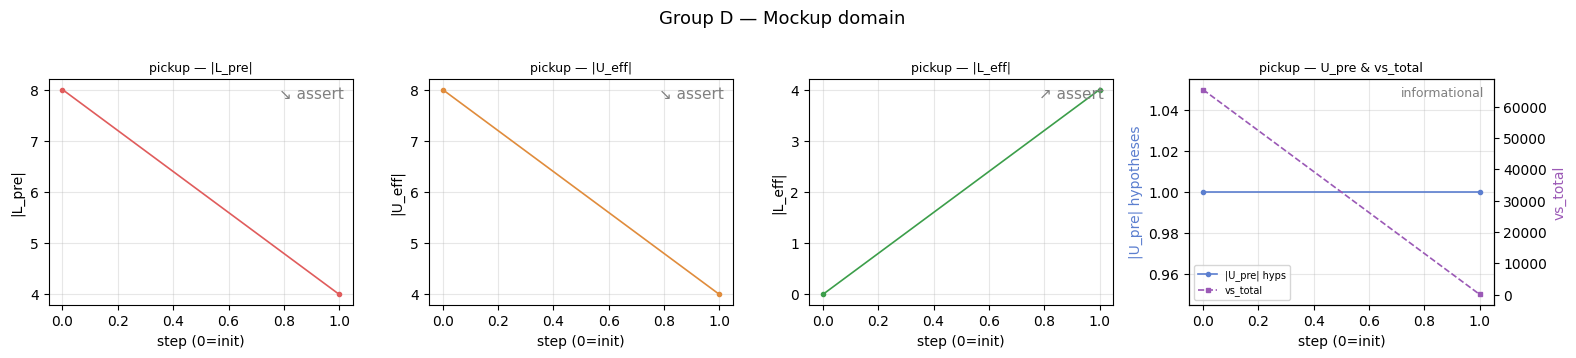

In [8]:
def plot_history(history, title=''):
    """Plot boundary size trajectories for each action.

    Each action gets one row with four panels:
      - L_pre literal count  (should be non-increasing)
      - U_eff literal count  (should be non-increasing)
      - L_eff literal count  (should be non-decreasing)
      - U_pre hypothesis count + version space total (informational)
    """
    action_names = list(history.keys())
    n_actions    = len(action_names)
    fig, axes    = plt.subplots(n_actions, 4,
                                figsize=(16, 3.5 * n_actions),
                                squeeze=False)
    if title:
        fig.suptitle(title, fontsize=13, y=1.01)

    for row, name in enumerate(action_names):
        h   = history[name]
        idx = list(range(len(h['demo_idx'])))

        # Colour x-axis ticks by demo kind
        kinds = h['demo_kind']

        def _plot(ax, values, ylabel, color, direction):
            ax.plot(idx, values, color=color, marker='o', markersize=3,
                    linewidth=1.2)
            ax.set_title(f'{name} — {ylabel}', fontsize=9)
            ax.set_xlabel('step (0=init)')
            ax.set_ylabel(ylabel)
            ax.annotate(direction, xy=(0.97, 0.97),
                        xycoords='axes fraction', ha='right', va='top',
                        fontsize=11, color='gray')
            ax.grid(True, alpha=0.3)

        _plot(axes[row][0], h['L_pre_lits'], '|L_pre|', '#e05c5c', '↘ assert')
        _plot(axes[row][1], h['U_eff_lits'], '|U_eff|', '#e08c3c', '↘ assert')
        _plot(axes[row][2], h['L_eff_lits'], '|L_eff|', '#3c9e4a', '↗ assert')

        # Combined informational panel
        ax4 = axes[row][3]
        ax4.plot(idx, h['U_pre_hyps'], color='#5b7ecf', marker='o',
                 markersize=3, linewidth=1.2, label='|U_pre| hyps')
        ax4_r = ax4.twinx()
        ax4_r.plot(idx, h['vs_total'], color='#9b59b6', marker='s',
                   markersize=3, linewidth=1.2, linestyle='--',
                   label='vs_total')
        ax4.set_title(f'{name} — U_pre & vs_total', fontsize=9)
        ax4.set_xlabel('step (0=init)')
        ax4.set_ylabel('|U_pre| hypotheses', color='#5b7ecf')
        ax4_r.set_ylabel('vs_total', color='#9b59b6')
        ax4.annotate('informational', xy=(0.97, 0.97),
                     xycoords='axes fraction', ha='right', va='top',
                     fontsize=9, color='gray')
        ax4.grid(True, alpha=0.3)
        lines1, labels1 = ax4.get_legend_handles_labels()
        lines2, labels2 = ax4_r.get_legend_handles_labels()
        ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=7,
                   loc='lower left')

    plt.tight_layout()
    plt.show()


plot_history(history_m, title='Group D — Mockup domain')

## Scale-up: Blocks Domain (4 actions, 20 problems)

In [9]:
BLOCKS_DIR    = os.path.join('..', 'benchmarks', 'blocks')
BLOCKS_DOMAIN = os.path.join(BLOCKS_DIR, 'domain_extended.pddl')
BLOCKS_PROBS  = os.path.join(BLOCKS_DIR, 'problems')

assert os.path.exists(BLOCKS_DOMAIN), f'Blocks domain not found: {BLOCKS_DOMAIN}'

problem_files = sorted(f for f in os.listdir(BLOCKS_PROBS) if f.endswith('.pddl'))
print(f'Blocks domain : {BLOCKS_DOMAIN}')
print(f'Problem files : {len(problem_files)}')

blocks_reader  = PDDLReader()
blocks_problem = blocks_reader.parse_problem(
    BLOCKS_DOMAIN, os.path.join(BLOCKS_PROBS, problem_files[0]))

b_fluents      = blocks_problem.fluents
b_actions      = blocks_problem.actions
b_static       = blocks_problem.get_static_fluents()
b_action_names = [a.name for a in b_actions]
print(f'Actions       : {b_action_names}')

Blocks domain : ../benchmarks/blocks/domain_extended.pddl
Problem files : 21
Actions       : ['pickup', 'putdown', 'stack', 'unstack']


In [10]:
# Collect unique lifted demos across all 20 problems (incremental dedup)
seen_pos, seen_neg     = set(), set()
all_pos_blocks, all_neg_blocks = [], []

for pf in problem_files:
    prob = blocks_reader.parse_problem(BLOCKS_DOMAIN, os.path.join(BLOCKS_PROBS, pf))
    tmpdir   = tempfile.mkdtemp(prefix='ascal_testD_blocks_')
    orig_cwd = os.getcwd()
    os.chdir(tmpdir)
    try:
        p, n = generate_demos(prob)
    finally:
        os.chdir(orig_cwd)
        shutil.rmtree(tmpdir, ignore_errors=True)

    new_p = new_n = 0
    for d in p:
        k = repr(d)
        if k not in seen_pos:
            seen_pos.add(k); all_pos_blocks.append(d); new_p += 1
    for d in n:
        k = repr(d)
        if k not in seen_neg:
            seen_neg.add(k); all_neg_blocks.append(d); new_n += 1

    print(f'  {pf}: +{new_p} new pos  +{new_n} new neg  '
          f'(unique so far: {len(all_pos_blocks)} pos, {len(all_neg_blocks)} neg)')

print(f'\nFinal unique: {len(all_pos_blocks)} pos, {len(all_neg_blocks)} neg')

  problem-00.pddl: +13 new pos  +548 new neg  (unique so far: 13 pos, 548 neg)
  problem-01.pddl: +9 new pos  +318 new neg  (unique so far: 22 pos, 866 neg)
  problem-02.pddl: +10 new pos  +266 new neg  (unique so far: 32 pos, 1132 neg)
  problem-03.pddl: +12 new pos  +113 new neg  (unique so far: 44 pos, 1245 neg)
  problem-04.pddl: +13 new pos  +261 new neg  (unique so far: 57 pos, 1506 neg)
  problem-05.pddl: +4 new pos  +47 new neg  (unique so far: 61 pos, 1553 neg)
  problem-06.pddl: +1 new pos  +39 new neg  (unique so far: 62 pos, 1592 neg)
  problem-07.pddl: +0 new pos  +20 new neg  (unique so far: 62 pos, 1612 neg)
  problem-08.pddl: +1 new pos  +30 new neg  (unique so far: 63 pos, 1642 neg)
  problem-09.pddl: +2 new pos  +23 new neg  (unique so far: 65 pos, 1665 neg)
  problem-10.pddl: +0 new pos  +3 new neg  (unique so far: 65 pos, 1668 neg)
  problem-11.pddl: +0 new pos  +0 new neg  (unique so far: 65 pos, 1668 neg)
  problem-12.pddl: +0 new pos  +0 new neg  (unique so far: 

In [11]:
violations_b, history_b = run_group_d(
    b_fluents, b_actions, b_static,
    all_pos_blocks, all_neg_blocks,
    label='Blocks domain (extended, 20 problems)'
)


=== Blocks domain (extended, 20 problems) ===
Sequence: 1744 demos (67 pos, 1677 neg)

D1 ✓  pickup: L_pre_lits  32 → 10  (non-increasing ↘)
D2 ✓  pickup: U_eff_lits  32 → 10  (non-increasing ↘)
D3 ✓  pickup: L_eff_lits  0 → 4  (non-decreasing ↗)
     pickup: U_pre_hyps  1 → 1  (informational — no strict direction)
     pickup: vs_total    18446744073709551616 → 8192  (informational)

D1 ✓  putdown: L_pre_lits  32 → 10  (non-increasing ↘)
D2 ✓  putdown: U_eff_lits  32 → 10  (non-increasing ↘)
D3 ✓  putdown: L_eff_lits  0 → 4  (non-decreasing ↗)
     putdown: U_pre_hyps  1 → 1  (informational — no strict direction)
     putdown: vs_total    18446744073709551616 → 32768  (informational)

D1 ✓  stack: L_pre_lits  32 → 12  (non-increasing ↘)
D2 ✓  stack: U_eff_lits  32 → 12  (non-increasing ↘)
D3 ✓  stack: L_eff_lits  0 → 5  (non-decreasing ↗)
     stack: U_pre_hyps  1 → 1  (informational — no strict direction)
     stack: vs_total    18446744073709551616 → 131072  (informational)

D1 ✓  

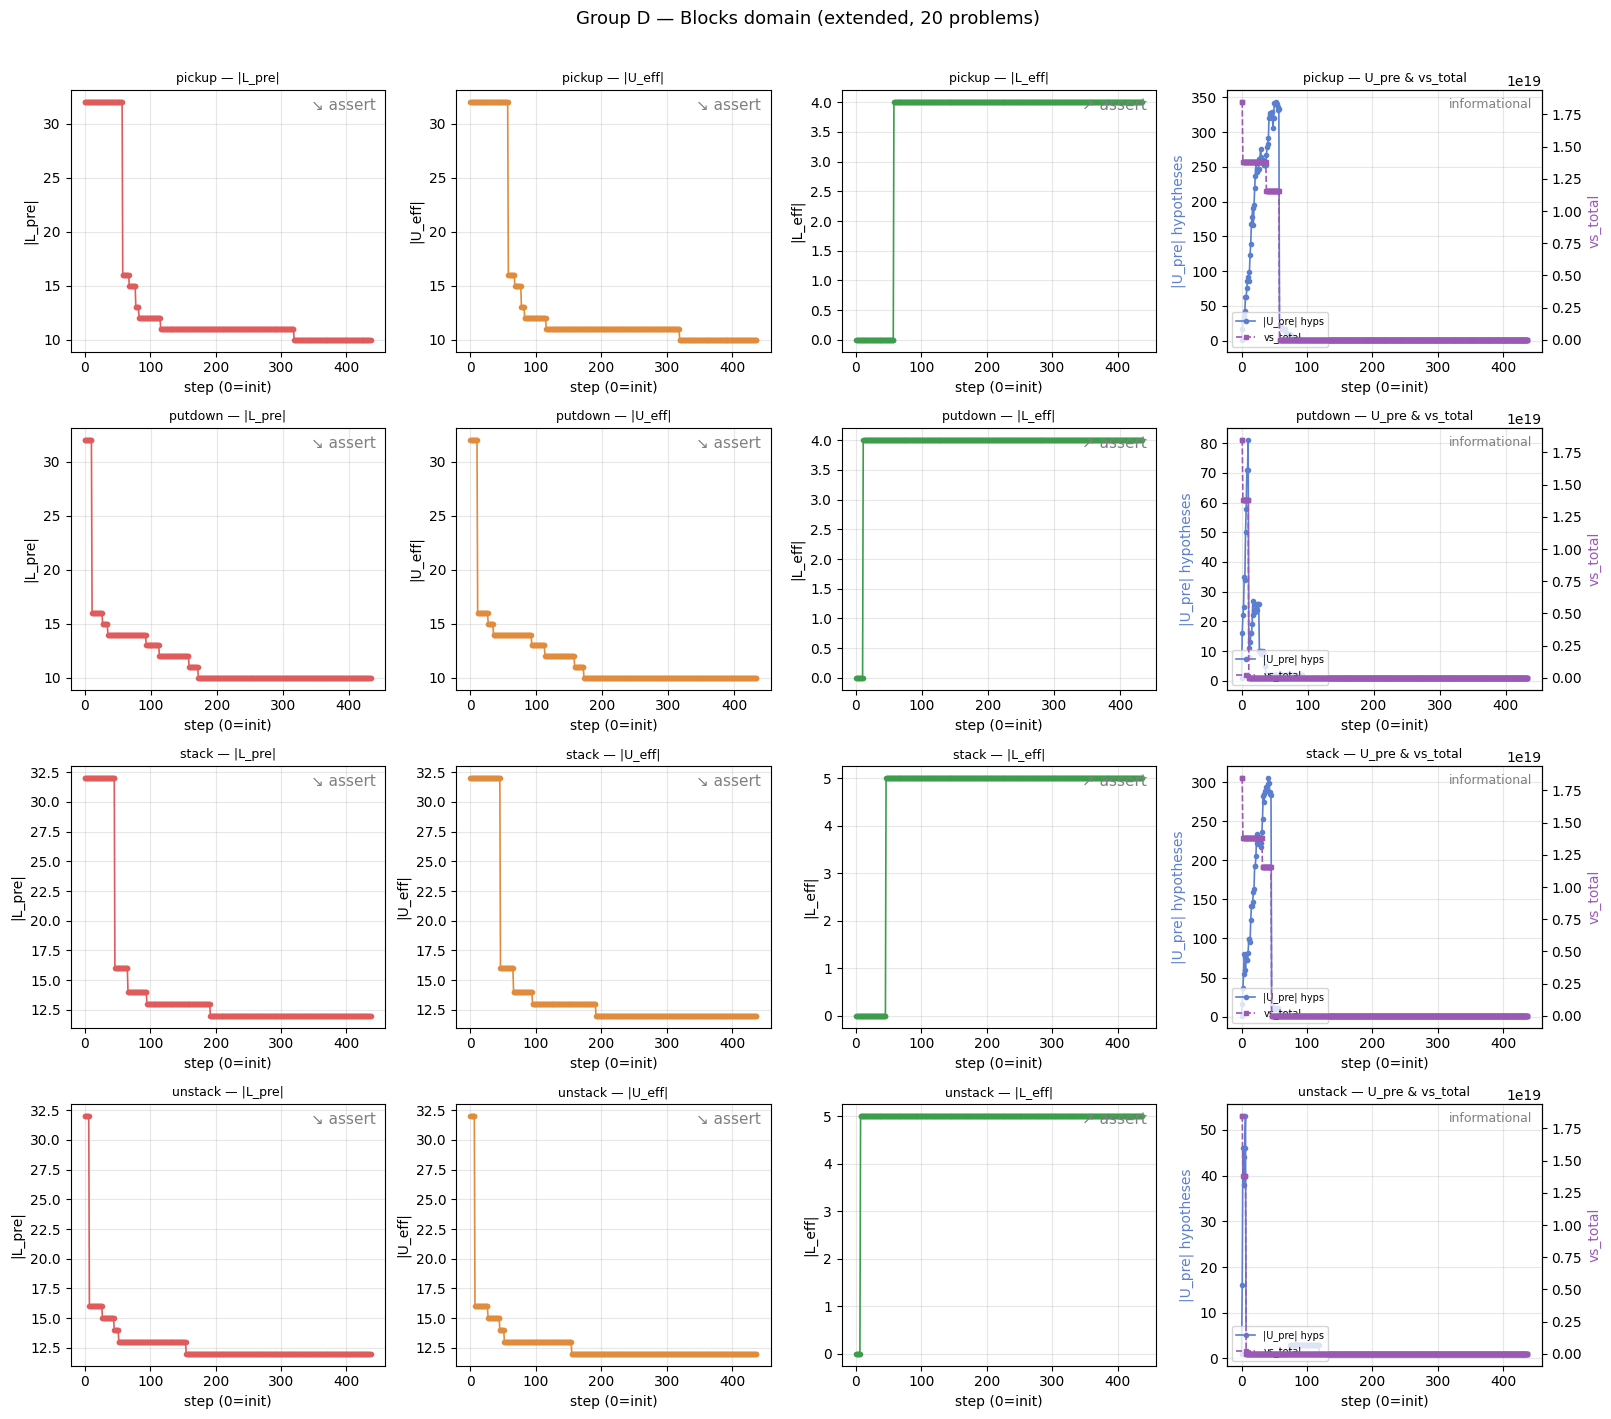

In [12]:
plot_history(history_b, title='Group D — Blocks domain (extended, 20 problems)')